In [1]:
%pip install matplotlib seaborn

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ------------------- ------------------ 41.0/80.3 kB 326.8 kB/s eta 0:00:01
     --------------------------------- ---- 71.7/80.3 kB 491.5 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 560.2 kB/s eta 0:00:00
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/127.4 kB ? eta -:--:--
     ------------------------- -------------- 81.9/127.4 kB ? eta -:--:--
     -------------------------------------- 127.4/127.4 kB 2.5 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
    --------------------------------------- 0.2/9.3 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
#1. import database / data

In [9]:
conn = sqlite3.connect("customer_churn.db")

sql_query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

tables = pd.read_sql(sql_query, conn)

# Create dataframe for each table

for table_name in tables['name']:
    
    df = pd.read_sql( 
        f"SELECT * FROM {table_name}",
        conn
    )
    
    globals()[f"df_{table_name}"] = df
    
    print(f"Created dataframe: df_{table_name}")

conn.close()

In [5]:
import sqlite3
import pandas as pd

# Connect to database
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()

In [16]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [15]:
import sqlite3
import pandas as pd

# Connect to the original database
conn = sqlite3.connect("../customer_churn.db")

# Load tables
df_db_customer = pd.read_sql(
    "SELECT * FROM db_customer",
    conn
)

df_db_subscription = pd.read_sql(
    "SELECT * FROM db_subscription",
    conn
)

df_db_support = pd.read_sql(
    "SELECT * FROM db_support",
    conn
)

conn.close()

print("Customer:", df_db_customer.shape)
print("Subscription:", df_db_subscription.shape)
print("Support:", df_db_support.shape)

Customer: (21, 8)
Subscription: (21, 11)
Support: (9, 6)


In [17]:
# Load the expanded 200-customer dataset

df_200 = pd.read_csv("../data/customer_churn_200_customers.csv")

print("Dataset Shape:", df_200.shape)

df_200.head()

Dataset Shape: (200, 25)


,customerid,customer_name,country,state,gender,dob,subscription_start_date,subscription_type,renewal_date,plan_type,...,churn_score,churn_flag,complaint_count,avg_csat,escalation_count,latest_complaint_date,tenure_days,tenure_months,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,2021-03-15,Referral,2025-03-15,Standard,...,12,0,0,NaN,0,NaN,1995,65.54,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,2020-08-01,Paid,2024-08-01,Premium,...,91,1,2,35.0,NY,2024-08-28,2221,72.97,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,2022-11-20,Organic,2025-11-20,Basic,...,34,0,0,NaN,0,NaN,1380,45.34,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,2019-05-10,Paid,2025-05-10,Premium,...,8,0,0,NaN,0,NaN,2670,87.72,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,2023-01-05,Referral,2024-01-05,Standard,...,88,1,1,20.0,Y,2024-01-20,1334,43.83,drama,NaN


In [18]:
print("Total rows:", len(df_200))
print("Total columns:", len(df_200.columns))
print("\nColumns:")
print(df_200.columns.tolist())

Total rows: 200
Total columns: 25

Columns:
['customerid', 'customer_name', 'country', 'state', 'gender', 'dob', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'complaint_count', 'avg_csat', 'escalation_count', 'latest_complaint_date', 'tenure_days', 'tenure_months', 'interests', 'pincode']


In [19]:
# Check missing values

missing_values = df_200.isnull().sum()

print(missing_values[missing_values > 0])

country                   24
cancellation_date        148
cancellation_reason      148
avg_csat                 139
latest_complaint_date    139
interests                161
pincode                  200
dtype: int64


In [20]:
# Check churn distribution

print(df_200['churn_flag'].value_counts())

print("\nChurn Rate:")
print(df_200['churn_flag'].mean() * 100)

churn_flag
0    148
1     52
Name: count, dtype: int64

Churn Rate:
26.0


In [21]:
# Check duplicate customer IDs

duplicate_count = df_200['customerid'].duplicated().sum()

print("Duplicate customer IDs:", duplicate_count)

Duplicate customer IDs: 0


In [22]:
# Check data types

print(df_200.dtypes)

customerid                  object
customer_name               object
country                     object
state                       object
gender                      object
dob                         object
subscription_start_date     object
subscription_type           object
renewal_date                object
plan_type                   object
contract_type               object
cancellation_date           object
cancellation_reason         object
monthly_charges            float64
cltv                         int64
churn_score                  int64
churn_flag                   int64
complaint_count              int64
avg_csat                   float64
escalation_count            object
latest_complaint_date       object
tenure_days                  int64
tenure_months              float64
interests                   object
pincode                    float64
dtype: object


In [23]:
# Convert date columns to datetime format

date_columns = [
    'dob',
    'subscription_start_date',
    'renewal_date',
    'cancellation_date',
    'latest_complaint_date'
]

for col in date_columns:
    df_200[col] = pd.to_datetime(df_200[col], errors='coerce')

print(df_200[date_columns].dtypes)

dob                        datetime64[ns]
subscription_start_date    datetime64[ns]
renewal_date               datetime64[ns]
cancellation_date          datetime64[ns]
latest_complaint_date      datetime64[ns]
dtype: object


In [24]:
# Validate churn flag against cancellation date

churn_check = pd.crosstab(
    df_200['churn_flag'],
    df_200['cancellation_date'].notna()
)

print(churn_check)

cancellation_date  False  True 
churn_flag                     
0                    148      0
1                      0     52


In [25]:
# Create a clean working copy for analysis

df = df_200.copy()

# Remove completely empty columns
df = df.drop(columns=['pincode'])

print("Analysis dataset shape:", df.shape)
print("Columns remaining:", len(df.columns))

Analysis dataset shape: (200, 24)
Columns remaining: 24


In [26]:
# Check support / customer experience data

print("Customers with support data:",
      df['avg_csat'].notna().sum())

print("Customers without support data:",
      df['avg_csat'].isna().sum())

print("\nCSAT summary:")
print(df['avg_csat'].describe())

Customers with support data: 61
Customers without support data: 139

CSAT summary:
count    61.000000
mean     38.532623
std      23.461450
min       8.760000
25%      22.210000
50%      30.000000
75%      46.480000
max      96.780000
Name: avg_csat, dtype: float64


In [27]:
# Complaint analysis

print("Customers with complaints:",
      (df['complaint_count'] > 0).sum())

print("Customers without complaints:",
      (df['complaint_count'] == 0).sum())

print("\nAverage complaints by churn status:")

complaint_by_churn = (
    df.groupby('churn_flag')['complaint_count']
      .mean()
      .reset_index()
)

complaint_by_churn['churn_status'] = complaint_by_churn['churn_flag'].map({
    0: 'Active',
    1: 'Churned'
})

complaint_by_churn['avg_complaints'] = (
    complaint_by_churn['complaint_count'].round(2)
)

print(
    complaint_by_churn[
        ['churn_status', 'avg_complaints']
    ]
)

Customers with complaints: 82
Customers without complaints: 118

Average complaints by churn status:
  churn_status  avg_complaints
0       Active            0.28
1      Churned            1.33


In [28]:
# Churn by contract type

contract_churn = (
    df.groupby('contract_type')
      .agg(
          customers=('customerid', 'nunique'),
          churned_customers=('churn_flag', 'sum')
      )
      .reset_index()
)

contract_churn['churn_rate'] = (
    contract_churn['churned_customers']
    / contract_churn['customers'] * 100
).round(2)

contract_churn = contract_churn.sort_values(
    'churn_rate',
    ascending=False
)

print(contract_churn)

  contract_type  customers  churned_customers  churn_rate
1       Monthly         76                 42       55.26
0        Annual        124                 10        8.06


In [29]:
# Churn by plan type

plan_churn = (
    df.groupby('plan_type')
      .agg(
          customers=('customerid', 'nunique'),
          churned_customers=('churn_flag', 'sum')
      )
      .reset_index()
)

plan_churn['churn_rate'] = (
    plan_churn['churned_customers']
    / plan_churn['customers'] * 100
).round(2)

plan_churn = plan_churn.sort_values(
    'churn_rate',
    ascending=False
)

print(plan_churn)

  plan_type  customers  churned_customers  churn_rate
0     Basic         53                 28       52.83
2  Standard         77                 14       18.18
1   Premium         70                 10       14.29


In [30]:
# Churn by subscription type

subscription_churn = (
    df.groupby('subscription_type')
      .agg(
          customers=('customerid', 'nunique'),
          churned_customers=('churn_flag', 'sum')
      )
      .reset_index()
)

subscription_churn['churn_rate'] = (
    subscription_churn['churned_customers']
    / subscription_churn['customers'] * 100
).round(2)

subscription_churn = subscription_churn.sort_values(
    'churn_rate',
    ascending=False
)

print(subscription_churn)

  subscription_type  customers  churned_customers  churn_rate
2          Referral         55                 42       76.36
1              Paid         50                 10       20.00
0           Organic         95                  0        0.00


In [31]:
# Customer Churn KPI Summary

kpi_summary = {
    'Total Customers': df['customerid'].nunique(),
    'Active Customers': (df['churn_flag'] == 0).sum(),
    'Churned Customers': (df['churn_flag'] == 1).sum(),
    'Churn Rate (%)': round(df['churn_flag'].mean() * 100, 2),
    'Avg Monthly Charges': round(df['monthly_charges'].mean(), 2),
    'Avg CLTV': round(df['cltv'].mean(), 2),
    'Avg Tenure (Months)': round(df['tenure_months'].mean(), 2),
    'Avg Complaints': round(df['complaint_count'].mean(), 2),
    'Avg CSAT': round(df['avg_csat'].mean(), 2)
}

for metric, value in kpi_summary.items():
    print(f"{metric}: {value}")

Total Customers: 200
Active Customers: 148
Churned Customers: 52
Churn Rate (%): 26.0
Avg Monthly Charges: 17.85
Avg CLTV: 812.75
Avg Tenure (Months): 58.11
Avg Complaints: 0.56
Avg CSAT: 38.53


In [32]:
# Compare average tenure between active and churned customers

tenure_by_churn = (
    df.groupby('churn_flag')['tenure_months']
      .mean()
      .reset_index()
)

tenure_by_churn['churn_status'] = tenure_by_churn['churn_flag'].map({
    0: 'Active',
    1: 'Churned'
})

tenure_by_churn['avg_tenure_months'] = (
    tenure_by_churn['tenure_months'].round(2)
)

print(
    tenure_by_churn[
        ['churn_status', 'avg_tenure_months']
    ]
)

  churn_status  avg_tenure_months
0       Active              60.15
1      Churned              52.29


In [33]:
# Compare average CLTV between active and churned customers

cltv_by_churn = (
    df.groupby('churn_flag')['cltv']
      .mean()
      .reset_index()
)

cltv_by_churn['churn_status'] = cltv_by_churn['churn_flag'].map({
    0: 'Active',
    1: 'Churned'
})

cltv_by_churn['avg_cltv'] = (
    cltv_by_churn['cltv'].round(2)
)

print(
    cltv_by_churn[
        ['churn_status', 'avg_cltv']
    ]
)

  churn_status  avg_cltv
0       Active    961.41
1      Churned    389.65


In [34]:
# Compare average monthly charges between active and churned customers

charges_by_churn = (
    df.groupby('churn_flag')['monthly_charges']
      .mean()
      .reset_index()
)

charges_by_churn['churn_status'] = charges_by_churn['churn_flag'].map({
    0: 'Active',
    1: 'Churned'
})

charges_by_churn['avg_monthly_charges'] = (
    charges_by_churn['monthly_charges'].round(2)
)

print(
    charges_by_churn[
        ['churn_status', 'avg_monthly_charges']
    ]
)

  churn_status  avg_monthly_charges
0       Active                19.87
1      Churned                12.09


In [35]:
# Compare average CSAT between active and churned customers

csat_by_churn = (
    df.groupby('churn_flag')['avg_csat']
      .mean()
      .reset_index()
)

csat_by_churn['churn_status'] = csat_by_churn['churn_flag'].map({
    0: 'Active',
    1: 'Churned'
})

csat_by_churn['avg_csat_score'] = (
    csat_by_churn['avg_csat'].round(2)
)

print(
    csat_by_churn[
        ['churn_status', 'avg_csat_score']
    ]
)

  churn_status  avg_csat_score
0       Active           87.76
1      Churned           30.01


In [ ]:
df_db_customer.info()


<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [ ]:
# a. rename col - name 
# b. drop columns - interest and pincode 
# c. change data type - dob
# d. data standaradization - gender
# e. fix missing values



In [ ]:
# a. rename col - name 

df_db_customer.rename(
    columns={'name': 'customer_name'},
    inplace=True
)


In [ ]:
sql_query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

tables = pd.read_sql(sql_query, conn)

tables

ProgrammingError: Cannot operate on a closed database.

In [ ]:
pd.read_sql(sql_query, conn)

ProgrammingError: Cannot operate on a closed database.

In [ ]:
import sqlite3

conn = sqlite3.connect("customer_churn.db")

print("Database connected successfully!")

Database connected successfully!


In [ ]:
sql_query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

tables = pd.read_sql(sql_query, conn)

tables

,name
0,db_customer
1,db_subscription
2,db_support


In [37]:
import sqlite3

conn = sqlite3.connect("../customer_churn.db")

print("Database connected successfully!")

Database connected successfully!


In [38]:
sql_query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

tables = pd.read_sql(sql_query, conn)

tables

,name
0,db_customer
1,db_subscription
2,db_support


In [39]:
import sqlite3

conn = sqlite3.connect("../customer_churn.db")

print("Database connected successfully!")

sql_query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

tables = pd.read_sql(sql_query, conn)

tables

Database connected successfully!


,name
0,db_customer
1,db_subscription
2,db_support


In [41]:
#Business Question: Which contract type has the highest customer churn rate?

In [42]:
sql_query = """
SELECT
    contract_type,
    COUNT(DISTINCT customerid) AS customers,
    SUM(
        CASE
            WHEN cancellation_date IS NOT NULL THEN 1
            ELSE 0
        END
    ) AS churned_customers,
    ROUND(
        100.0 * SUM(
            CASE
                WHEN cancellation_date IS NOT NULL THEN 1
                ELSE 0
            END
        ) / COUNT(DISTINCT customerid),
        2
    ) AS churn_rate
FROM db_subscription
GROUP BY contract_type
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(sql_query, conn)

result

,contract_type,customers,churned_customers,churn_rate
0,Monthly,9,5,55.56
1,Annual,12,1,8.33


In [43]:
# nsight: Monthly-contract customers had a substantially higher observed churn rate (55.56%) than annual-contract customers (8.33%) in the analyzed dataset. This indicates that contract type is strongly associated with churn in this dataset.

In [44]:
sql_query = """
SELECT
    c.state,
    COUNT(DISTINCT c.customerid) AS customers,
    SUM(
        CASE
            WHEN s.cancellation_date IS NOT NULL THEN 1
            ELSE 0
        END
    ) AS churned_customers,
    ROUND(
        100.0 * SUM(
            CASE
                WHEN s.cancellation_date IS NOT NULL THEN 1
                ELSE 0
            END
        ) / COUNT(DISTINCT c.customerid),
        2
    ) AS churn_rate
FROM db_customer c
LEFT JOIN db_subscription s
    ON c.customerid = s.customerid
GROUP BY c.state
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(sql_query, conn)

result

,state,customers,churned_customers,churn_rate
0,Karnataka,2,2,100.00
1,Meghalaya,3,2,66.67
2,Telangana,2,1,50.00
3,Delhi,4,1,25.00
4,Uttar Pradesh,2,0,0.00
5,Rajasthan,2,0,0.00
6,Nagaland,1,0,0.00
7,Maharashtra,3,0,0.00
8,Kathmandu,2,0,0.00


In [ ]:
for table_name in tables['name']:
    
    df = pd.read_sql(
        f"SELECT * FROM {table_name}",
        conn
    )
    
    globals()[f"df_{table_name}"] = df
    
    print(f"Created dataframe: df_{table_name}")

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [ ]:
# create dataframe for each table

for table_name in tables['name']:
    
    df = pd.read_sql(
        f"SELECT * FROM {table_name}",
        conn
    )
    
    globals()[f"df_{table_name}"] = df
    
    print(f"Created dataframe: df_{table_name}")

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [ ]:
df_db_customer.head()
df_db_subscription.head()
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [ ]:
df_db_customer.rename(
    columns={'name': 'customer_name'},
    inplace=True
)

In [ ]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [ ]:
df_db_customer.drop(
    columns=['interests', 'pincode'],
    inplace=True
)

In [ ]:
#df_db_customer.head()
df_db_customer.tail()

,customerid,customer_name,country,state,gender,dob
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00


In [ ]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     21 non-null     str  
 1   customer_name  21 non-null     str  
 2   country        18 non-null     str  
 3   state          21 non-null     str  
 4   gender         21 non-null     str  
 5   dob            21 non-null     str  
dtypes: str(6)
memory usage: 1.1 KB


In [ ]:
df_db_customer.dtypes

customerid       str
customer_name    str
country          str
state            str
gender           str
dob              str
dtype: object

In [ ]:
# c. change data type - dob
df_db_customer['dob'] = pd.to_datetime(
    df_db_customer['dob'],
    errors='coerce'
)

In [ ]:
df_db_customer.dtypes

customerid                  str
customer_name               str
country                     str
state                       str
gender                      str
dob              datetime64[us]
dtype: object

In [ ]:
# d. data standaradization - gender
#df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({
    'Men': 'Male',
    'Women': 'Female',
    'Woman': 'Female'
})

In [ ]:
df_db_customer['gender'].value_counts()

gender
Female    12
Male       9
Name: count, dtype: int64

In [ ]:
# e. fix missing values -country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [ ]:
df_db_customer[df_db_customer['country'].isnull()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [ ]:
df_db_customer['country'].isnull().sum()

np.int64(3)

In [ ]:
df_db_customer[df_db_customer['country'].isnull()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [ ]:
df_db_customer.loc[
    df_db_customer['customerid'] == '0013-MHZWF',
    'country'
] = 'India'

df_db_customer.loc[
    df_db_customer['customerid'] == '0015-UOCOJ',
    'country'
] = 'Nepal'

df_db_customer.loc[
    df_db_customer['customerid'] == '0018-NYROU',
    'country'
] = 'India'

In [ ]:
df_db_customer['country'].isnull().sum()

np.int64(0)

In [ ]:
df_db_customer['country'].value_counts()

country
India    19
Nepal     2
Name: count, dtype: int64

In [ ]:
df_db_customer.dropna(subset=['country']).set_index('state')

,customerid,customer_name,country,gender,dob
state,,,,,
Maharashtra,0002-ORFBO,keshav,India,Male,1982-04-12
Karnataka,0003-MKNFE,raghav,India,Male,1995-11-23
Delhi,0004-TLHLJ,lalita,India,Female,1978-02-15
Nagaland,0011-IGKFF,mohan,India,Male,2001-08-30
Delhi,0013-EXCHZ,mira,India,Female,1990-05-05
Delhi,0013-MHZWF,durga,India,Female,1988-12-10
Meghalaya,0013-SMEOE,mina,India,Female,1976-09-21
Rajasthan,0014-BMAQU,madan,India,Male,1999-03-14
Kathmandu,0015-UOCOJ,maya,Nepal,Female,1985-07-07


In [ ]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        21 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [ ]:
df_db_customer.isnull().sum()

customerid       0
customer_name    0
country          0
state            0
gender           0
dob              0
dtype: int64

In [ ]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [ ]:
df_db_subscription.isnull().sum()

customerid                  0
subscription_start_date     0
subscription_type           0
renewal_date                0
plan_type                   0
contract_type               0
cancellation_date          15
cancellation_reason        15
monthly_charges             0
cltv                        0
churn_score                 0
dtype: int64

In [ ]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [ ]:
df_db_subscription['subscription_start_date'] = pd.to_datetime(
    df_db_subscription['subscription_start_date'],
    errors='coerce'
)

df_db_subscription['renewal_date'] = pd.to_datetime(
    df_db_subscription['renewal_date'],
    errors='coerce'
)

df_db_subscription['cancellation_date'] = pd.to_datetime(
    df_db_subscription['cancellation_date'],
    errors='coerce'
)

In [ ]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [ ]:
state_country_mapping = df_db_customer.dropna(
    subset=['country']
).set_index('state')['country'].to_dict()

In [ ]:
state_country_mapping

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Telangana': 'India',
 'Uttar Pradesh': 'India'}

In [ ]:
# country and state - unique value pair
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [ ]:
state_country_mapping

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Telangana': 'India',
 'Uttar Pradesh': 'India'}

In [ ]:
state_country_mapping = df_db_customer.dropna(
    subset=['country']
).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(
    df_db_customer['state'].map(state_country_mapping)
)

In [ ]:
df_db_customer['country'].isnull().sum()

np.int64(0)

In [ ]:
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [ ]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [ ]:
date_col = [
    'subscription_start_date',
    'renewal_date',
    'cancellation_date'
]

df_db_subscription[date_col] = df_db_subscription[date_col].apply(
    pd.to_datetime
)

In [ ]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [ ]:
df_db_subscription[date_col]
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [ ]:
 df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [ ]:
 df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [ ]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [ ]:
 df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 420.0 bytes


In [ ]:
# Feature Engineering and data analysis

In [ ]:
#create a new column using existing col- churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1,0)

In [ ]:
df_db_subscription[['customerid', 'cancellation_date', 'churn_flag']]

,customerid,cancellation_date,churn_flag
0,0002-ORFBO,NaT,0
1,0003-MKNFE,2024-09-10,1
2,0004-TLHLJ,NaT,0
3,0011-IGKFF,NaT,0
4,0013-EXCHZ,2024-02-28,1
5,0013-MHZWF,NaT,0
6,0013-SMEOE,2024-11-15,1
7,0014-BMAQU,NaT,0
8,0015-UOCOJ,NaT,0
9,0016-QLJIS,NaT,0


In [ ]:
df_db_subscription['churn_flag'].value_counts()

churn_flag
0    15
1     6
Name: count, dtype: int64

In [ ]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [ ]:
# marging the data using joins 
#uses SQL Joins (specifically implemented via Pandas merge with how='left') because the dataset is split across three separate relational database tables:

In [ ]:

# first fix  the support table duplicates then merge
df=(df_db_subscription.merge(df_db_customer, on='customerid', how='left')
                             .merge(df_db_support, on='customerid', how='left'))


In [ ]:
df_merged.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05


In [ ]:
df_merged.shape

(21, 17)

In [ ]:
df_db_subscription['customerid'].nunique()

21

In [ ]:
df_db_customer['customerid'].nunique()

21

In [ ]:
df_db_support['customerid'].nunique()

7

In [ ]:
df_db_support['customerid'].size

9

In [ ]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [ ]:
# learning GROUP BY

In [ ]:
df_db_support['complain_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [ ]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complain_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [ ]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [ ]:
df_db_support['customerid'].size

7

In [ ]:
# merge df (dataframe)
df=(df_db_subscription.merge(df_db_customer, on='customerid', how='left')
                             .merge(df_db_support, on='customerid', how='left'))

In [ ]:
df.shape

(21, 21)

In [ ]:
df.to_csv('exported_churn_data.csv', index=False)

In [ ]:
# data analysis 

In [ ]:
# 1. Churn Rate

In [ ]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count'],
      dtype='str')

In [ ]:
churn_rate = df['churn_flag'].mean()*100
print("churn_rate=",round(churn_rate,2),"%")

churn_rate= 28.57 %


In [ ]:
# 2. Reduction Rate 

In [ ]:
# Calculate retention rate
retention_rate = 100 - churn_rate

# Print formatted result
print("Retention_rate =", round(retention_rate, 2), "%")

Retention_rate = 71.43 %


In [ ]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [ ]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [ ]:
# 3. churn by plan type (which type of customers are leaving)


In [ ]:
df.groupby('plan_type')['churn_flag'].mean().reset_index()
# storing in variable:   .reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [ ]:
churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
print("churn by plan=\n", churn_by_plan)

churn by plan=
   plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [ ]:
#----home work***
# 4 a. churn by state + sum of revanue and count of users
#   b.   churn by subscription 

In [ ]:
# 5. ARPU avg revanue per user 
arpu=df['monthly_charges'].mean()
print('ARPU=', round(arpu,2))

ARPU= 18.85


In [ ]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count'],
      dtype='str')

In [ ]:
#

In [ ]:
# 6.Avg customer Teure
# count of days user has used our servidc :  cancellation date 
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(), 
    (df['cancellation_date'] - df['subscription_start_date']).dt.days, 
    (today - df['subscription_start_date']).dt.days
)


avg_tenure = df['tenure_days'].mean ()
print("Avr Tenure(Days) =", round(avg_tenure),0)


      

Avr Tenure(Days) = 1537 0


In [ ]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days'],
      dtype='str')

In [ ]:
# 7. revenue at risk - revanue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revanue at Risk(Rs 'k')=", revenue_at_risk)

Revanue at Risk(Rs 'k')= 73.94


In [ ]:
# 8. Esclation Rate 
# 8. Escalation Rate calculation using uppercase 'Y'
escalation_rate = (df['escalations'] == 'Y').mean() * 100

print("Escalation Rate =", round(escalation_rate, 2), "%")
                  

Escalation Rate = 19.05 %


In [ ]:
print(df.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'complain_count', 'tenure_days']


In [ ]:

# 9. Avg complaint per user
# Calculate Average Complaints Per User
avg_complain_per_user = df['complain_count'].sum() / df['customerid'].nunique()
print("Avg Complain Per User =", round(avg_complain_per_user,2))

Avg Complain Per User = 0.43


In [ ]:
# 10. correlation Escationa Vs Churn 
## alo using where condition 
corr_df =df[['escalations', 'churn_flag']].dropna()
#df['escalations'] = np.where(df['escalations']== 'y', 1, 0) # encoding string to int type
correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print("correlation between  Escationa Vs Churn is =", round(correlation,2))

correlation between  Escationa Vs Churn is = nan


In [ ]:
# 11. Churn Risk - Create a column using existing column - churn risk 
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low', 'medium', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unknown')
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,gender,dob,complaint_date,escalations,csat_score,complain_count,tenure_days,escalations_encoded,escalations_clean,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Male,1982-04-12,NaT,0,NaN,NaN,2007.0,0,0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Male,1995-11-23,2024-08-28,0,10.0,2.0,1501.0,0,0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,Female,1978-02-15,NaT,0,NaN,NaN,1392.0,0,0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,Male,2001-08-30,NaT,0,NaN,NaN,2682.0,0,0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Female,1990-05-05,2024-01-20,0,20.0,1.0,419.0,0,0,high


In [ ]:
df[['churn_risk','churn_score']].tail()

,churn_risk,churn_score
16,medium,62
17,low,27
18,high,99
19,low,7
20,low,47


In [ ]:
# data visualization usind matplotlib

In [ ]:
#df.head is same as df_visual
df_visual =df.copy() 

In [ ]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days', 'escalations_encoded', 'escalations_clean',
       'churn_risk'],
      dtype='str')

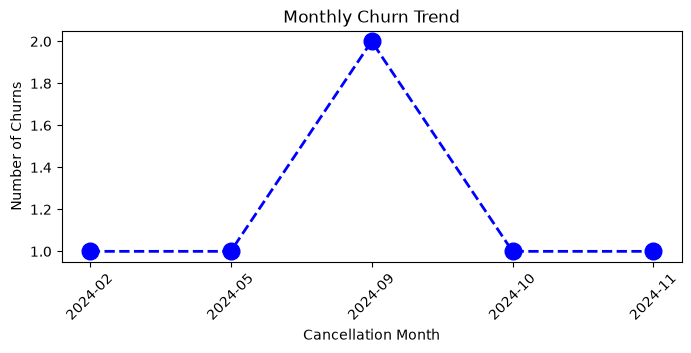

In [ ]:
# 1. Extract cancellation month as period
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

# 2. Store the grouped series in churn_trend
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

# 3. Plot the monthly churn trend line graph
plt.figure(figsize=(8,3))
plt.plot(
    churn_trend.index.astype(str), 
    churn_trend.values, 
    marker='o', 
    color='blue',
    linestyle='dashed', 
    linewidth=2, 
    markersize=12
)

# Optional labels for a complete chart
plt.xlabel('Cancellation Month')
plt.ylabel('Number of Churns')
plt.title('Monthly Churn Trend')
plt.xticks(rotation=45)
plt.show()

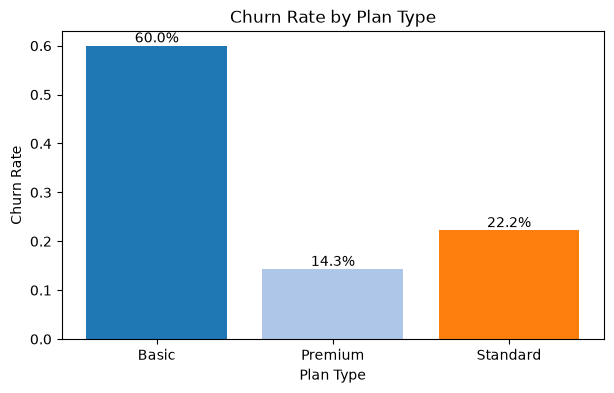

In [ ]:
# 4.2 Churn by Plan Type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize=(7, 4))
bars = plt.bar(churn_plan.index, churn_plan.values, color=['#1f77b4', '#aec7e8', '#ff7f0e'])

# Chart styling
plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate')

# Display percentages on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height, 
        f'{height * 100:.1f}%', 
        ha='center', 
        va='bottom'
    )

plt.show()

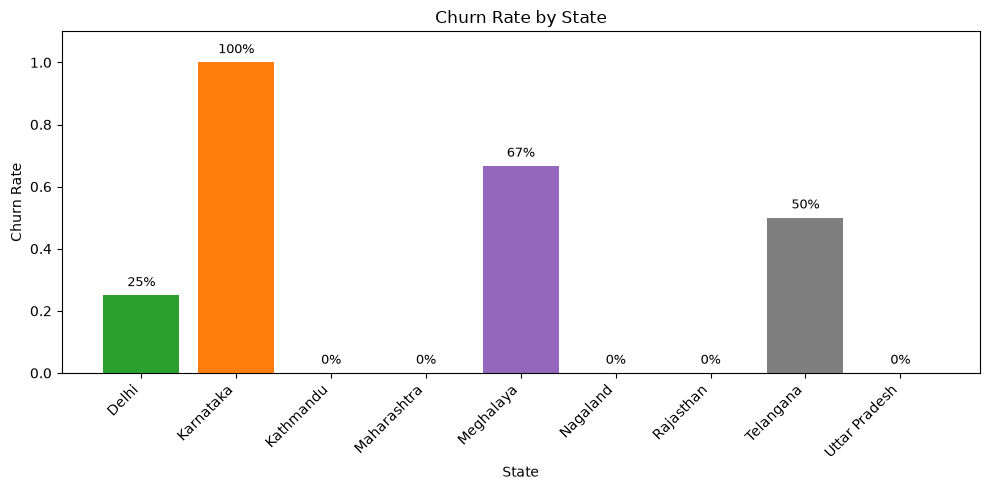

In [ ]:
# 4.3 Churn by State with custom bar colors
churn_state = df_visual.groupby('state')['churn_flag'].mean()

# Define color palette matching the video chart
colors = ['#2ca02c', '#ff7f0e', '#d62728', '#1f77b4', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']

plt.figure(figsize=(10, 5))
bars = plt.bar(churn_state.index, churn_state.values, color=colors[:len(churn_state)])

# Add exact percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height + 0.02, 
        f'{height * 100:.0f}%', 
        ha='center', 
        va='bottom',
        fontsize=9
    )

# Rotate state names to prevent overlapping
plt.xticks(rotation=45, ha='right')

plt.title('Churn Rate by State')
plt.xlabel('State')
plt.ylabel('Churn Rate')
plt.ylim(0, 1.1)  # Gives margin at the top for percentage labels

plt.tight_layout()
plt.show()

In [ ]:
# Visualization using seaborn

In [ ]:
# encoding - converting str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days', 'escalations_encoded', 'escalations_clean', 'churn_risk',
       'cancellation_month'],
      dtype='str')

In [ ]:
# Select specific columns using double brackets [[ ... ]]
columns_to_keep = [
    'plan_type', 'contract_type', 'churn_score', 'churn_flag', 
    'churn_risk', 'escalations'
]

# Create encoded/filtered DataFrame
df_encoded = df_visual[columns_to_keep].copy()

# If you need to convert categorical text columns to string type:
categorical_cols = ['plan_type', 'contract_type', 'churn_risk']
df_encoded[categorical_cols] = df_encoded[categorical_cols].astype(str)

df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,0


In [ ]:
# 1. Create a copy of the subset to avoid SettingWithCopyWarning
df_encoded = df_visual[[
    'plan_type', 'contract_type', 'churn_score', 'churn_flag', 
    'churn_risk', 'escalations'
]].copy()

# 2. Encode categorical columns into numeric codes
categorical_cols = ['plan_type', 'contract_type', 'churn_risk']    

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# 3. View the encoded dataset
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,0
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,0


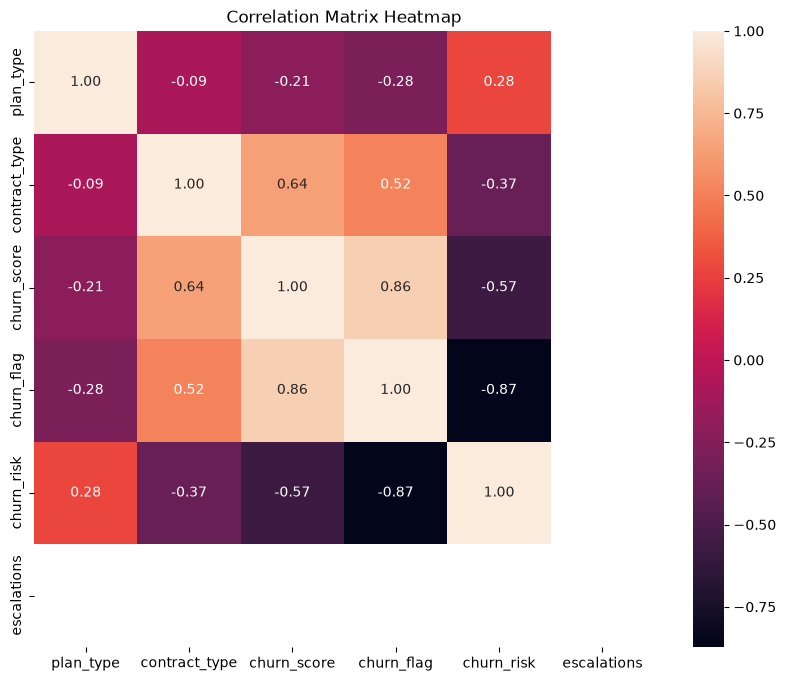

In [ ]:
# Correlation Heatmap matching video styling
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_encoded.corr(), 
    annot=True, 
    fmt='.2f', 
    cmap='rocket'
)

plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].copy()

order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'medium', 'high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

# Encode escalations ('Y' -> 1, 'N' -> 0)
df_encoded['escalations'] = np.where(df_encoded['escalations'] == 'Y', 1, 0)

# Display encoded DataFrame
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,0
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,0


In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='rocket')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
# 10. CSAT vs Churn

csat_analysis = (
    df.groupby('churn_flag')['csat_score']
      .mean()
      .reset_index()
)

csat_analysis['churn_status'] = csat_analysis['churn_flag'].map({
    0: 'Active',
    1: 'Churned'
})

csat_analysis['avg_csat'] = csat_analysis['csat_score'].round(2)

print(csat_analysis[['churn_status', 'avg_csat']])

  churn_status  avg_csat
0       Active     90.00
1      Churned     34.17


<Axes: >

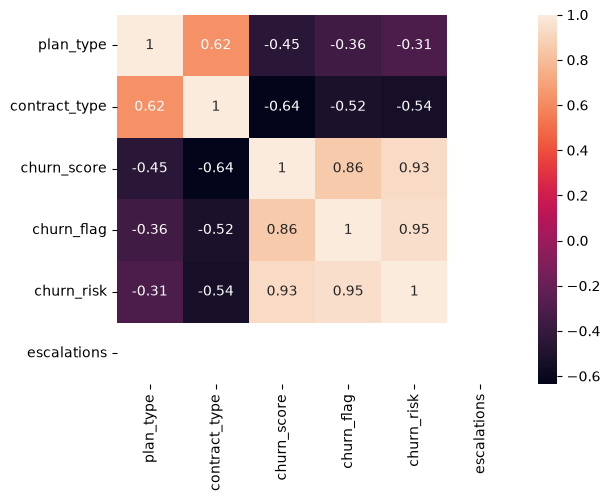

In [ ]:
sns.heatmap(
    df_encoded.corr(), 
    annot=True)

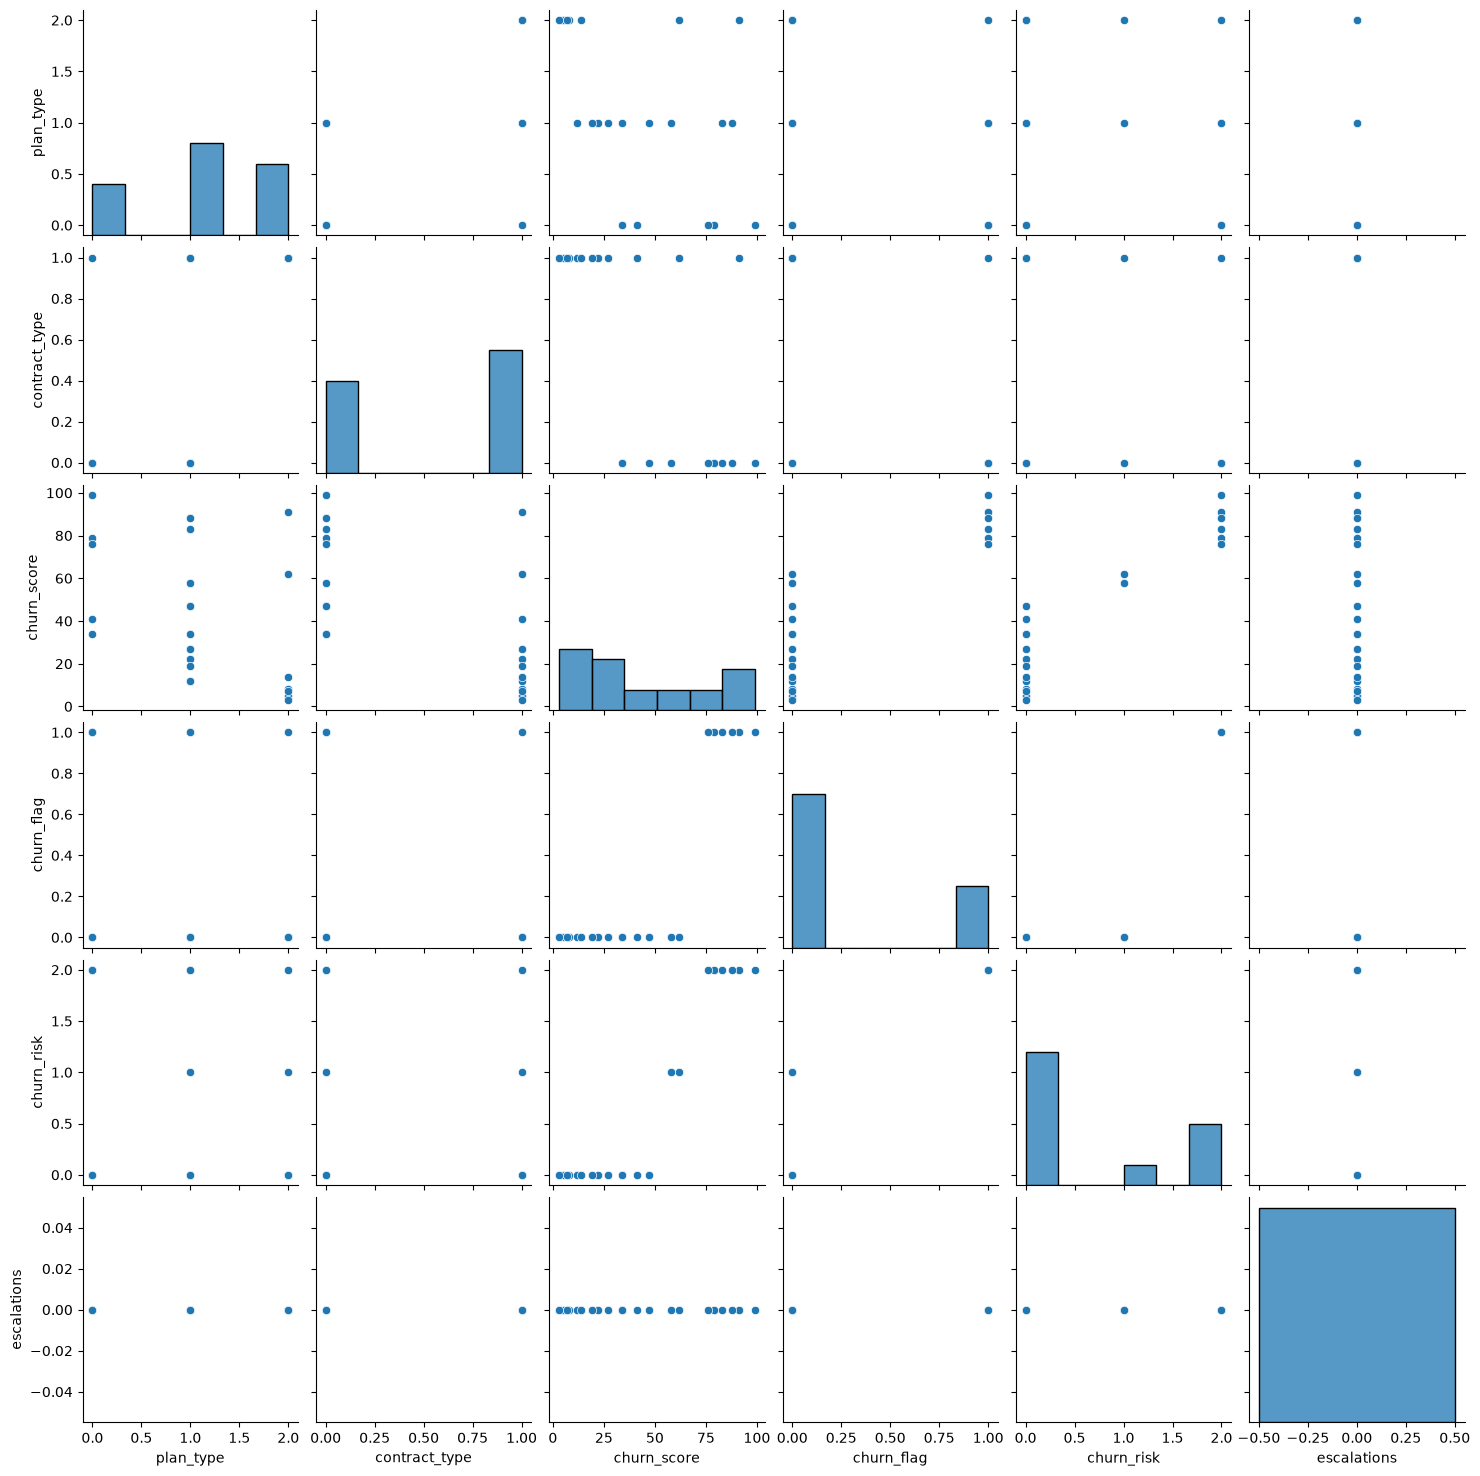

In [ ]:
# paurplot - (Relationship in a dataset)
sns.pairplot(df_encoded)

In [ ]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days', 'escalations_encoded', 'escalations_clean', 'churn_risk',
       'cancellation_month'],
      dtype='str')

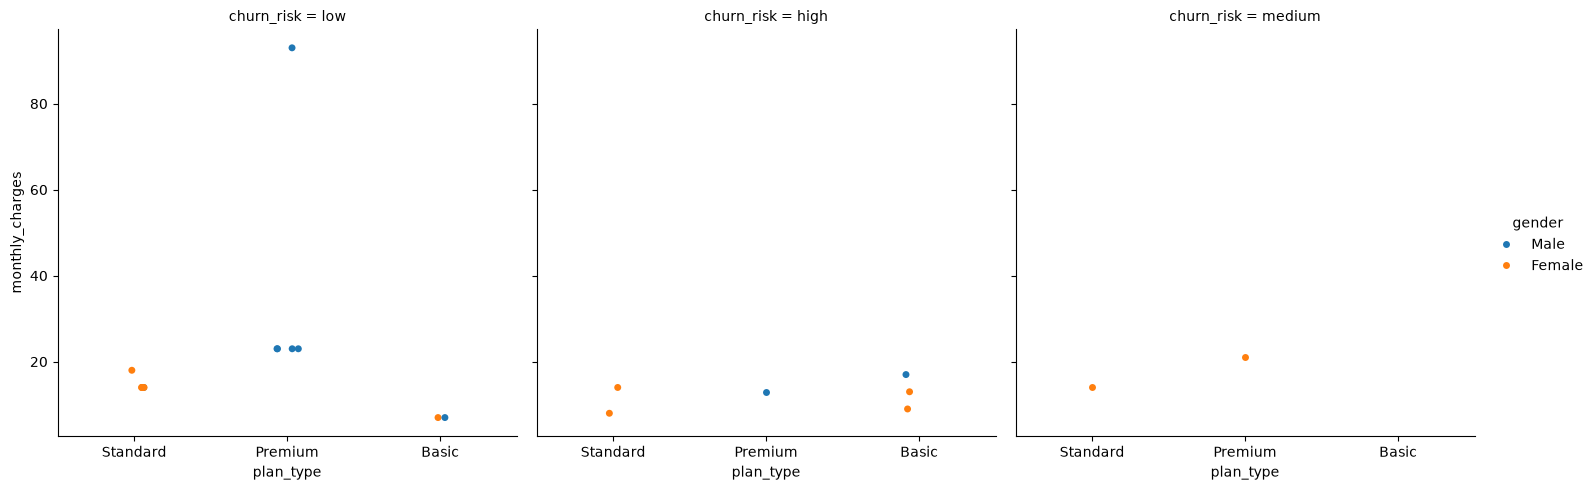

In [ ]:
# catplt/factorial plot - multi dimension comparision

sns.catplot(data=df_visual,

    x='plan_type',
    y='monthly_charges',
    hue='gender',

    col='churn_risk')

In [ ]:
# pivot table

In [ ]:
# pd.pivot_table (funtion too use pivot table )
pd.pivot_table(
    df_visual,
    values= 'churn_flag',
    index='plan_type',
    aggfunc='mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [ ]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days', 'escalations_encoded', 'escalations_clean', 'churn_risk',
       'cancellation_month'],
      dtype='str')

In [ ]:
pd.pivot_table(
    df_visual,
    values=['customerid', 'monthly_charges', 'churn_flag'],
    index='plan_type',
    aggfunc={
        'customerid': 'nunique',      # Unique count of customers
        'monthly_charges': 'mean',    # Average monthly charges
        'churn_flag': 'mean'          # Average churn rate
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,10.590000
Premium,0.142857,7,31.275714
Standard,0.222222,9,13.767778


In [ ]:
# working with SQL in python (pandas)

In [ ]:
import sqlite3

# 1. Create database connection
conn = sqlite3.connect('test_database.sqlite')

# 2. Create table details
conn.execute("CREATE TABLE USERS (first_name TEXT, country TEXT, budget INTEGER)")

# 3. Commit and close
conn.commit()


In [ ]:
import sqlite3

# 1. Re-open connection (since it was previously closed)
conn = sqlite3.connect('test_database.sqlite')
cursor = conn.cursor()

# 2. Prepare sample data tuples
users_data = [
    ('Rishabh', 'India', 2000),
    ('Elisabeth', 'Germany', 3000),
    ('David', 'Mexico', 1000)
]

# 3. Execute SQL insertion
cursor.executemany(
    """
    INSERT INTO USERS (first_name, country, budget)
    VALUES (?, ?, ?)
    """,
    users_data
)

# 4. Commit changes and close connection
conn.commit()
conn.close()

print ("data inserted successfully")

data inserted successfully


In [ ]:
# check inseted data in table
conn = sqlite3.connect('test_database.sqlite')
query = """ SELECT * FROM USERS"""
df_result = pd.read_sql(query, conn)
df_result.head()

,first_name,country,budget
0,Rishabh,India,2000
1,Elisabeth,Germany,3000
2,David,Mexico,1000
3,Rishabh,India,2000
4,Elisabeth,Germany,3000


In [ ]:
# aggrigation
query = """
SELECT country , sum(budget) as total_budget FROM users
GROUP BY country
"""
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,6000
1,India,4000
2,Mexico,2000


In [ ]:
# always close conn with db once task is over
conn.close()